## 9. Evaluation on Test/Validation Data
We can evaluate the model to check its accuracy and generate a confusion matrix to see where it might be making mistakes.

In [1]:
%pip install kaggle tensorflow matplotlib
import os
import shutil

# The dataset is already downloaded.
# The leapgestrecog dataset has structure: leapGestRecog/00/01_palm/img.png
# We need to organize it into organized_dataset/01_palm/img.png
DATASET_DIR = './leapgestrecog_retry/leapGestRecog'
ORGANIZED_DIR = './organized_dataset'

if not os.path.exists(ORGANIZED_DIR):
    os.makedirs(ORGANIZED_DIR)
    
# Check if dataset exists yet
if os.path.exists(DATASET_DIR) and not os.listdir(ORGANIZED_DIR):
    print("Organizing dataset...")
    for subject_id in os.listdir(DATASET_DIR):
        subject_path = os.path.join(DATASET_DIR, subject_id)
        if not os.path.isdir(subject_path):
            continue
        for gesture_name in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture_name)
            if not os.path.isdir(gesture_path):
                continue
            
            target_gesture_dir = os.path.join(ORGANIZED_DIR, gesture_name)
            if not os.path.exists(target_gesture_dir):
                os.makedirs(target_gesture_dir)
            
            for img_name in os.listdir(gesture_path):
                src = os.path.join(gesture_path, img_name)
                # to avoid name collision, prefix with subject_id
                dst = os.path.join(target_gesture_dir, f"{subject_id}_{img_name}")
                shutil.copy2(src, dst)
    print("Dataset organized.")

DATASET_PATH = ORGANIZED_DIR # Update the path variable for the rest of the notebook

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Highly Efficient Machine Learning Model Structure

This notebook provides a structured, highly efficient pipeline for training a machine learning model (e.g., for Hand Gesture Detection) and exporting it for use in a Flutter application (via TensorFlow Lite).

## 1. Setup and Imports
Import necessary libraries. We use TensorFlow/Keras as it offers great support for mobile deployment via TFLite.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## 2. Efficient Data Loading Pipeline (`tf.data`)
To train over a dataset highly efficiently, we use `tf.data.Dataset`. This allows asynchronous data loading, prefetching, and parallel transformations.

In [3]:
# Configuration variables
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224
# DATASET_PATH is now set in the first cell

# Efficient Data Loading using tf.keras.utils.image_dataset_from_directory
def create_dataset(data_dir, is_training=True):
    dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2 if is_training else None,
        subset="training" if is_training else None,
        seed=123,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE
    )
    
    # Store class names before prefetching
    class_names = dataset.class_names
    
    # Performance optimization: caching and prefetching
    AUTOTUNE = tf.data.AUTOTUNE
    dataset = dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    
    # Attach class names back to the prefetched dataset
    dataset.class_names = class_names
    return dataset

# Uncomment and update paths when data is available
train_dataset = create_dataset(DATASET_PATH, is_training=True)
val_dataset = tf.keras.utils.image_dataset_from_directory(DATASET_PATH, validation_split=0.2, subset='validation', seed=123, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 5755 files belonging to 10 classes.
Using 4604 files for training.
Found 5755 files belonging to 10 classes.
Using 1151 files for validation.


## 3. Data Augmentation
Applying data augmentation inside the model structure ensures it is GPU-accelerated and exported with the model.

In [4]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomZoom(0.1),
])


## 4. Model Architecture
For mobile apps (Flutter), lightweight architectures like MobileNetV2 are highly recommended for fast inference and small model size.

In [5]:
def build_efficient_model(num_classes):
    # Use MobileNetV2 as the base model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze the base model for transfer learning initially
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = data_augmentation(inputs)
    
    # Preprocess inputs for MobileNetV2 (scales pixels to [-1, 1])
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    return model

NUM_CLASSES = len(train_dataset.class_names) # Dynamically inferred from dataset
print(f'Detected {NUM_CLASSES} classes: {train_dataset.class_names}')
model = build_efficient_model(NUM_CLASSES)
model.summary()

Detected 10 classes: ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Compilation and Training Callbacks
Define early stopping and learning rate reduction for efficient training.

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3)
]

## 6. Training Loop
Run the training process using the efficient datasets.

In [7]:
EPOCHS = 20

# Uncomment to train when dataset is ready
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


c:\Users\alias\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


144/144 ━━━━━━━━━━━━━━━━━━━━ 138s 840ms/step - accuracy: 0.8703 - loss: 0.5311 - val_accuracy: 0.9679 - val_loss: 0.1726 - learning_rate: 0.0010
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 105s 732ms/step - accuracy: 0.9911 - loss: 0.0909 - val_accuracy: 0.9957 - val_loss: 0.0951 - learning_rate: 0.0010
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 107s 747ms/step - accuracy: 0.9954 - loss: 0.0488 - val_accuracy: 0.9948 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 124s 861ms/step - accuracy: 0.9959 - loss: 0.0348 - val_accuracy: 0.9965 - val_loss: 0.0529 - learning_rate: 0.0010
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 123s 859ms/step - accuracy: 0.9963 - loss: 0.0274 - val_accuracy: 1.0000 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 118s 821ms/step - accuracy: 0.9976 - loss: 0.0207 - val_accuracy: 0.9983 - val_loss: 0.0394 - learning_rate: 0.0010
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 120s 834ms/step - accuracy: 0.9985 

## 7. Fine-tuning (Optional but recommended)
Unfreeze the top layers of the base model for better performance.

In [8]:
# Extract the base model from our wrapped model
base_model = None
for layer in model.layers:
    if hasattr(layer, 'layers'):
        base_model = layer
        break

base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_fine = model.fit(train_dataset, validation_data=val_dataset, epochs=10, callbacks=callbacks)


Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 114s 737ms/step - accuracy: 0.9987 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0078 - learning_rate: 1.0000e-04
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 103s 719ms/step - accuracy: 0.9996 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 0.0095 - learning_rate: 1.0000e-04
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 104s 723ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0082 - learning_rate: 1.0000e-04
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 106s 736ms/step - accuracy: 0.9996 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0072 - learning_rate: 1.0000e-04
Epoch 5/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 112s 780ms/step - accuracy: 0.9996 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0078 - learning_rate: 1.0000e-04
Epoch 6/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 104s 726ms/step - accuracy: 0.9998 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0080 - learning_rate: 1.0000e-04
Epoch 7/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 

## 8. Export to TensorFlow Lite
Convert the trained model to TFLite format to be integrated into the Flutter app seamlessly.

In [9]:
def export_to_tflite(model, tflite_model_path='gesture_model.tflite'):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # Optional: Apply quantization for a smaller, faster model (useful for mobile)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    tflite_model = converter.convert()
    
    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_model)
    print(f"TFLite model saved to {tflite_model_path}")

# Uncomment to export
export_to_tflite(model)

INFO:tensorflow:Assets written to: C:\Users\alias\AppData\Local\Temp\tmp78mx6fhk\assets


INFO:tensorflow:Assets written to: C:\Users\alias\AppData\Local\Temp\tmp78mx6fhk\assets


Saved artifact at 'C:\Users\alias\AppData\Local\Temp\tmp78mx6fhk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2411095041296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095041872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095042256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095042064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095039760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095042640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095043792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095043984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095042832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2411095042448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

## 9. Evaluation on Test/Validation Data
We can evaluate the model to check its accuracy and generate a confusion matrix to see where it might be making mistakes.

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 262.6 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 196.9 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 271.2 kB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB 991.0 kB/s eta 0:00:09
   ---------------------------------------- 0.1/8.3 MB 1.3 MB/s eta 0:00:07
   ---------------------------------------- 0.1/8.3 MB


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Evaluating model on validation data...
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 511ms/step - accuracy: 1.0000 - loss: 0.0069
Validation Loss: 0.0069
Validation Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       113
         02_l       1.00      1.00      1.00        99
      03_fist       1.00      1.00      1.00       122
04_fist_moved       1.00      1.00      1.00       132
     05_thumb       1.00      1.00      1.00       120
     06_index       1.00      1.00      1.00       127
        07_ok       1.00      1.00      1.00       128
08_palm_moved       1.00      1.00      1.00       110
         09_c       1.00      1.00      1.00       108
      10_down       1.00      1.00      1.00        92

     accuracy                           1.00      1151
    macro avg       1.00      1.00      1.00      1151
 weighted avg       1.00      1.00      1.00      1151



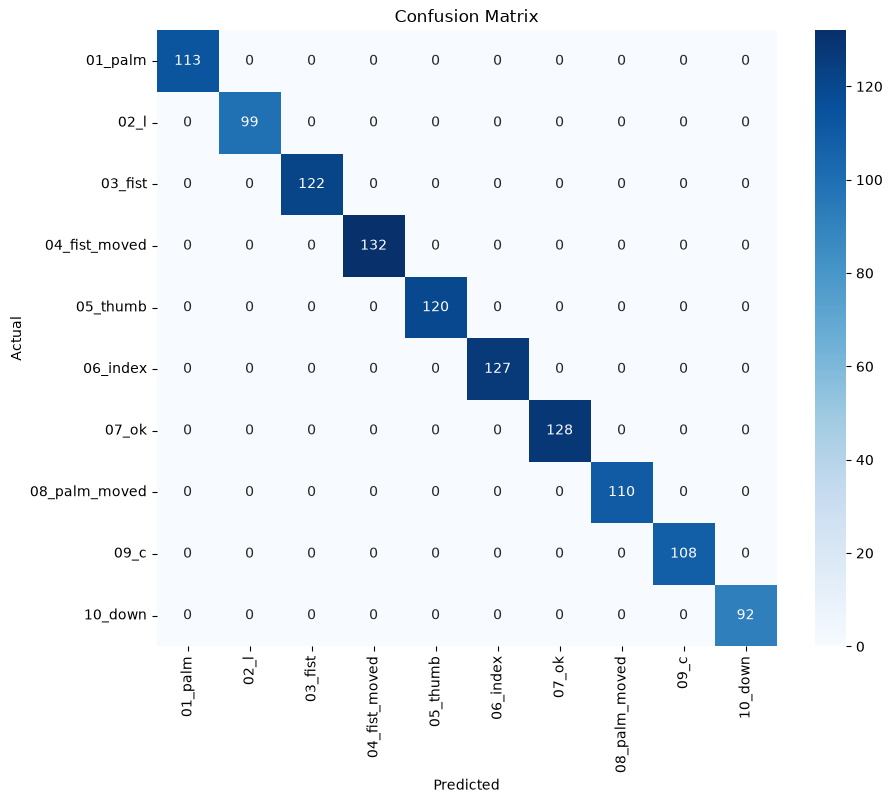

In [10]:
%pip install scikit-learn seaborn
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("Evaluating model on validation data...")
loss, accuracy = model.evaluate(val_dataset)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Extract true labels and predictions
y_true = []
y_pred = []
for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Class names are ordered alphabetically in image_dataset_from_directory
class_names = [
    "01_palm", "02_l", "03_fist", "04_fist_moved", "05_thumb", 
    "06_index", "07_ok", "08_palm_moved", "09_c", "10_down"
]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()